In [2]:
nb_id = 'prod01'

In [3]:
from pathlib import Path
from math import isnan, nan

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize, TwoSlopeNorm, to_rgba
from matplotlib.lines import Line2D
from matplotlib import colormaps

import astropy.units as u
import astropy.constants as ct
from scipy.signal import find_peaks
from scipy.interpolate import interp1d

import mesa_reader as mr

import sys
sys.path.append('..')
from src.star import fix_unit
from src.binary import a_from_p, p_from_a, eggleton_rl1_radius, marchant_l2_radius
from src.util import DATA_DIR, MESA_DATA_DIR
from src.constants import Z_SUN

plt.style.use('./plotstyle.mplstyle')
FIGURE_FOLDER = Path(f'./output/nb{nb_id}/figures')
FIGURE_FOLDER.mkdir(parents=True, exist_ok=True)
plt.style.use('./plotstyle.mplstyle')

# Notebook 01: Step-by-step argument for the CHE contribution to the mass distribution

In this argument, we build our argument for what defines the shape of the CHE contribution to the $m_1$ distribution in GWs in a set of 3 steps. Each step extracts the strongest reasonable conclusion possible for the available data, before adding extra assumptions in the next step. This serves to elucidate the way in which CHE could create a feature at $35\,{\rm M}_\odot$. 

**Step 1:** assumes nothing but our very MESA tracks, demonstrating that they already pile-up to a relatively narrow range in the final masses and delay times. However, the delay time cut produces a strong lower cut-off, not a pile-up.


**Step 2:** assumes an IMF, orbital period and mass ratio distributions for fixed metallicity. Demonstrates that, for fixed metallicity, the product IMF X CHE WINDOW creates a peak a few solar masses above the lower edge of the CHE window. Demonstrates that this peak is always dominant because it is inherently tied to the shortest delay times (least mass loss, least orbital widening). Demonstrates that for increasing metallicity the maximum BH mass decreases and accumulates a pile-up. Demonstrates that for some metallicities the wind pile-up merges with the CHE IMF peak.


**Step 3:** assumes a metallicity-dependent star formation rate. Demonstrates that, within the delay time cutoff, the SFRD priviledges the metallicities with the narrowest, CHE IMF peak concentrated metallicities. Demonstrates that a combination of low masses and mass-loss/orbital widening means that any system below the lower edge of the CHE window does not merge. The peak at the lower edge then emerges because every metallicity that produces mergers produces a primary peak at the lower edge + a high-mass tail/peak for the lowest metallicities. WE can fit D_ES to get the window to close at 35. The CHE contributions dies off rapidly below and needs to be supplemented by a different channel. We get a broad peak with a long high mass tail and a sharp low mass cut which is compatible with the GWTC5 slope-break model.

## Step 1: MESA track argument

In [338]:
# ── user settings ────────────────────────────────────────────────────────────
MDOT_CMAP      = 'plasma'    # colormap for metallicity colour coding
N_CORES        = 30          # parallel workers for loading
STEP           = 1           # load every STEP-th qualifying file (1 = all)
C_DEPL_THRESH  = 1e-3        # center_c12 depletion threshold
TRACK_ALPHA    = 0.01         # opacity of individual tracks
TRACK_LW       = 1           # linewidth of individual tracks
HULL_ALPHA     = 0.1         # opacity of envelope fill
N_GRID         = 500         # M-grid resolution for the envelope plot
LOGMDOT_FLOOR  = -6          # floor applied to log|Mdot| after loading, -6 is good for Y>0.3, -8 if taking the whole track
HE4_ONSET      = 0.3         # surface He4 onset threshold (None = full track)
TRACKS_PLOT_STEP = 1          # subsample tracks[::step] in per-Z panel plots
ENDPOINT_SIZE  = 24         # marker size for endpoint scatter (HRD)
CONTOUR_RES    = 15         # bins per axis for HRD mass-weighted contour (low = quick)
CONTOUR_LEVELS = 2          # number of contour levels for HRD mass-weighted contour
TRACK_GRAY_ALPHA = 0.2      # alpha for grayscale track ensemble (HRD)
T_H = 13.7e9

# ── mass column (used everywhere m_f is plotted) ──────────────────────────────
MASS_COL = 'm_f'   # 'm_f' | 'm_post_pi' | 'm_tams' | 'm_zams'
_M = {'m_f': r'm_\mathrm{f}', 'm_post_pi': r'm_\mathrm{post{-}pi}',
      'm_tams': r'm_\mathrm{TAMS}', 'm_zams': r'm_\mathrm{ZAMS}'}.get(MASS_COL, MASS_COL)
MASS_LABEL       = rf'${_M}$ / $\mathrm{{M}}_\odot$'
MASS_DELTA_LABEL = rf'$\Delta {_M} / \Delta m_\mathrm{{i}}$'
MASS_DN_LABEL    = rf'$\mathrm{{d}}N_\mathrm{{w}}/\mathrm{{d}}{_M}$'

In [5]:
ZDIVZSUN_VALS = {
    z_label: _zdivzsun(folder_name)
    for z_label, (_, folder_name) in metallicity_map.items()
}

# C-depletion stop criterion (mirrors run_star_extras.f90 lines 224–231)
_C12_THRESH = 1e-3
_HE4_THRESH = 5e-3
_H1_THRESH  = 0.5

NameError: name 'metallicity_map' is not defined

In [209]:
def plot_logtd_panels(td_tracks, he4_onset=HE4_ONSET,
                       cmap_name=MDOT_CMAP, alpha=TRACK_ALPHA, lw=TRACK_LW, tracks_step=TRACKS_PLOT_STEP):
    """[D_Z] One panel per metallicity: log10(delay time / yr) vs log(M/Msun).

    Single solid black t_Hubble line sets the merger region (td < tH, white)
    vs non-merger region (td > tH, light-gray fill). Inverted x-axis (high
    mass left). Bottom 1/3: logM endpoint histogram. Right side: log_td
    endpoint histogram. Vertical mass line marks the highest-mass merger
    track; scatter highlights endpoints inside the merger region; bars
    outside the merger region are drawn at lower alpha.
    """
    from src.constants import cosmo as _cosmo
    z_labels  = list(metallicity_map.keys())
    N         = len(z_labels)
    zdivzsuns = [ZDIVZSUN_VALS[z] for z in z_labels]
    cmap_obj  = plt.get_cmap(cmap_name)
    colors    = [cmap_obj(i / max(N - 1, 1)) for i in range(N)]

    # ── Auto limits ─────────────────────────────────────────────────────────
    all_log_td = np.concatenate([
        log_td for z in z_labels for (_, log_td) in td_tracks[z]
    ]) if any(td_tracks[z] for z in z_labels) else np.array([6.0, 12.0])
    all_logM = np.concatenate([
        logM for z in z_labels for (logM, _) in td_tracks[z]
    ]) if any(td_tracks[z] for z in z_labels) else np.array([1.0, 2.5])
    fin_td = all_log_td[np.isfinite(all_log_td)]
    fin_M  = all_logM[np.isfinite(all_logM)]

    y_floor    = np.percentile(fin_td, 1)  - 0.3
    y_top      = fin_td.max() + 0.5
    y_pad      = (3.0 * y_floor - y_top) / 2.0
    left_range = y_top  - y_pad
    hist_range = (y_floor - y_pad) - 0.05

    x_sep = np.percentile(fin_M, 1)  - 0.05
    x_max = np.percentile(fin_M, 99) + 0.15

    ltd_bin_w = 0.2
    ltd_bins  = np.arange(
        np.floor(fin_td.min() / ltd_bin_w) * ltd_bin_w,
        np.ceil( fin_td.max() / ltd_bin_w) * ltd_bin_w + ltd_bin_w,
        ltd_bin_w,
    )

    fig, axes = plt.subplots(
        N, 1, figsize=(12, 18), dpi=300,
        sharex=True, gridspec_kw={'hspace': 0.06},
    )
    fig.subplots_adjust(left=0.15, right=0.85)

    fig_w_in, fig_h_in = fig.get_size_inches()
    ax_h_in  = fig_h_in * 0.87 / N
    ax_w_in  = fig_w_in * 0.70
    x_hist_w = (hist_range / left_range) * (ax_h_in / ax_w_in) * (x_max - x_sep)
    x_left   = x_sep - x_hist_w

    # ── Hubble time (single global limit) ───────────────────────────────────
    log_t_hubble = np.log10(_cosmo.age(0).to(u.yr).value)

    # Shared style for t_H line, mass separator, and histogram spines
    LINE_KW = dict(color='black', lw=0.6, zorder=3)

    for i, (z_label, zdivzsun, color) in enumerate(zip(z_labels, zdivzsuns, colors)):
        ax = axes[i]
        ax.set_ylim(y_pad, y_top)
        ax.set_xlim(x_max, x_left)   # inverted: high mass on left

        # Histogram separator spines (thin solid black)
        #ax.axhline(y_floor, **LINE_KW)
        #ax.axvline(x_sep,   **LINE_KW)

        # Non-merger overlay above t_Hubble (covers tracks + histograms, low opacity)
        ax.fill_between([x_left, x_max], log_t_hubble, y_top,
                        color='lightgray', alpha=0.3, zorder=10, linewidth=0)

        # Tracks
        logM_ends   = []
        log_td_ends = []
        for logM, log_td in td_tracks[z_label][::tracks_step]:
            valid = np.isfinite(logM) & np.isfinite(log_td)
            if valid.sum() < 2:
                continue
            ax.plot(logM[valid], log_td[valid],
                    color=color, alpha=alpha, lw=lw, rasterized=True)
            logM_ends.append(logM[valid][-1])
            log_td_ends.append(log_td[valid][-1])

        # t_Hubble line (single, thin solid black)
        ax.axhline(log_t_hubble, ls='--', **LINE_KW)

        # ── Merger mass cut + scatter ────────────────────────────────────────
        m_cut = None
        if log_td_ends:
            m_arr  = np.array(logM_ends)
            td_arr = np.array(log_td_ends)
            mask   = td_arr <= log_t_hubble
            if mask.any():
                m_cut = float(m_arr[mask].max())
                ax.vlines(m_cut, ymin=y_pad, ymax=log_t_hubble, ls='--', **LINE_KW)
                # Non-merger overlay for the high-mass strip below t_H (down through the bottom histogram)
                ax.fill_between([m_cut, x_max], y_pad, log_t_hubble,
                                color='lightgray', alpha=0.3, zorder=10, linewidth=0)
                in_box = (m_arr <= m_cut) & (td_arr <= log_t_hubble)
                if in_box.any():
                    ax.scatter(m_arr[in_box], td_arr[in_box],
                               s=22, c=[color], edgecolors='black',
                               linewidths=0.4, zorder=5)

        # Region labels
        ax.text(0.15, 0.75, r'$t_\mathrm{d} > t_\mathrm{H}$',
                transform=ax.transAxes, ha='center', va='center', fontsize=11)
        ax.text(x_sep, y_floor, r'$t_\mathrm{d} < t_\mathrm{H}$',
                ha='right', va='top', fontsize=11)

        # ── Bottom histogram: logM endpoints (twinx) ─────────────────────────
        ax_r = ax.twinx()
        if logM_ends:
            all_ends = np.array(logM_ends)
            mbin_w = 0.01
            mbins  = np.arange(
                np.floor(all_ends.min() * 100) / 100,
                np.ceil( all_ends.max() * 100) / 100 + mbin_w, mbin_w,
            )
            counts, bin_edges = np.histogram(all_ends, bins=mbins)
            bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
            max_c = int(counts.max())
            ax_r.set_ylim(0, max_c * left_range / hist_range)
            if m_cut is not None:
                in_mask = bin_centers <= m_cut
                if in_mask.any():
                    ax_r.bar(bin_centers[in_mask], counts[in_mask], width=mbin_w * 0.9,
                             color=color, alpha=0.7, linewidth=0, align='center')
                if (~in_mask).any():
                    ax_r.bar(bin_centers[~in_mask], counts[~in_mask], width=mbin_w * 0.9,
                             color=color, alpha=0.5, linewidth=0, align='center')
            else:
                ax_r.bar(bin_centers, counts, width=mbin_w * 0.9,
                         color=color, alpha=0.7, linewidth=0, align='center')
        ax_r.set_yticks([])

        # ── Right histogram: log_td endpoints ────────────────────────────────
        if log_td_ends:
            counts_td, edges_td = np.histogram(log_td_ends, bins=ltd_bins)
            max_c_td   = int(counts_td.max()) if counts_td.max() > 0 else 1
            bar_w_norm = counts_td / max_c_td * x_hist_w * 0.9
            bar_centers = 0.5 * (edges_td[:-1] + edges_td[1:])
            in_mask = bar_centers <= log_t_hubble
            if in_mask.any():
                ax.barh(bar_centers[in_mask], bar_w_norm[in_mask], left=x_left,
                        height=ltd_bin_w * 0.9, color=color, alpha=0.7, linewidth=0)
            if (~in_mask).any():
                ax.barh(bar_centers[~in_mask], bar_w_norm[~in_mask], left=x_left,
                        height=ltd_bin_w * 0.9, color=color, alpha=0.5, linewidth=0)

        ax.text(0.005, 0.97,
                rf'${zdivzsun:.3g}\,\mathrm{{Z}}_\odot$',
                transform=ax.transAxes, va='top', ha='left', fontsize=12,
                bbox=dict(facecolor=color, alpha=0.55, edgecolor='none', boxstyle='round,pad=0.3'))
        ax.tick_params(axis='x', direction='in', labelbottom=False)
        ax.tick_params(axis='y', direction='in')

    axes[-1].tick_params(axis='x', labelbottom=True)
    axes[-1].set_xlabel(r'$\log M/\mathrm{M}_\odot$')
    onset_str = rf'onset $Y_\mathrm{{surf}} \geq {he4_onset}$' if he4_onset is not None else 'full track'
    axes[0].set_title(rf'[D_Z]  {onset_str}')
    fig.text(0.07, 0.5, r'$\log_{10}(t_\mathrm{d}/\mathrm{yr})$',
             va='center', ha='center', rotation='vertical')
    fig.text(0.93, 0.5, r'$\leftarrow$ count',
             va='center', ha='center', rotation='vertical', fontsize=9)
    return fig, axes


## Step 2: IMF X CHE WINDOW, fixed-metallicity argument

In [75]:
sample_df_path = DATA_DIR / "ip_pop_minz0.0005_maxz1.0_res1e+08_interpolator_00fiducial_df.h5"
sample00_df = pd.read_hdf(sample_df_path, key='df')

In [76]:
sample00_df.columns.values

array(['z_div_zsun', 'm_zams', 'p_spin_zams', 'm_f', 'p_orb_f', 'x_f',
       'x_min_f', 'm_tams', 'x_tams', 'log_t_d', 'm_post_pi', 'fate_type'],
      dtype=object)

In [81]:
sample00_df[~np.isnan(sample00_df.m_f)].max()

z_div_zsun       0.398842
m_zams         299.877478
p_spin_zams      3.123233
m_f             94.479141
p_orb_f         563.67093
x_f              3.186863
x_min_f          0.049468
m_tams         114.859936
x_tams           8.395188
log_t_d         16.050332
m_post_pi       49.928291
fate_type           ppisn
dtype: object

(array([1025.,  926.,  867.,  874.,  837.,  633.,  553.,  495.,  418.,
         266.]),
 array([-1.69881777, -1.56885595, -1.43889414, -1.30893233, -1.17897051,
        -1.0490087 , -0.91904689, -0.78908507, -0.65912326, -0.52916145,
        -0.39919964]),
 <BarContainer object of 10 artists>)

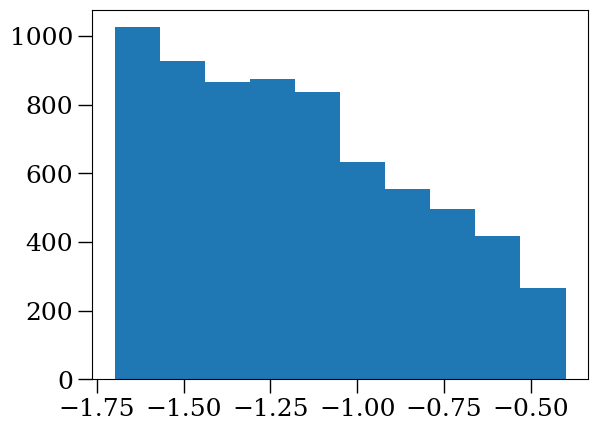

In [77]:
plt.hist(np.log10(sample00_df[~np.isnan(sample00_df.m_f)].z_div_zsun.to_numpy()))

In [78]:
import seaborn as sns

In [ ]:
# plot settings
## data
log_z_div_zsun_edges = np.arange(-1.8, -0.3, 0.2)
m_f_bins = np.arange(9, 100, 2)

## look
figsize = (10, 6)
dpi = 100
cmap = cm.viridis

# plot setup
fig, ax = plt.subplots(figsize=figsize, dpi=dpi)

for i, (log_z_div_zsun_ledge, log_z_div_zsun_uedge) in enumerate(zip(log_z_div_zsun_edges[:-1], log_z_div_zsun_edges[1:])):
    color = cmap(i / (len(log_z_div_zsun_edges) - 1))
    z_div_zsun_mask = (sample00_df['z_div_zsun'] >= 10**log_z_div_zsun_ledge) & (sample00_df['z_div_zsun'] < 10**log_z_div_zsun_uedge)
    subset = sample00_df[z_div_zsun_mask]
    subset = subset[~np.isnan(subset[MASS_COL])]
    sns.histplot(subset[MASS_COL], alpha=1, color=color, bins=m_f_bins)

ax.set_yscale('log')
ax.set_ylim(1e1)
ax.set_xlabel(MASS_LABEL)

In [ ]:
# plot settings
## data
log_z_div_zsun_edges = np.arange(-1.8, -0.3, 0.2)
m_f_bins = np.arange(9, 100, 2)

## look
figsize = (10, 6)
dpi = 100
cmap = cm.viridis

# plot setup
fig, ax = plt.subplots(figsize=figsize, dpi=dpi)

bin_width = m_f_bins[1] - m_f_bins[0]
bin_centers = 0.5 * (m_f_bins[:-1] + m_f_bins[1:])
bottom = np.zeros(len(bin_centers))

for i, (log_z_div_zsun_ledge, log_z_div_zsun_uedge) in enumerate(zip(log_z_div_zsun_edges[:-1], log_z_div_zsun_edges[1:])):
    color = cmap(i / (len(log_z_div_zsun_edges) - 1))
    z_div_zsun_mask = (sample00_df['z_div_zsun'] >= 10**log_z_div_zsun_ledge) & (sample00_df['z_div_zsun'] < 10**log_z_div_zsun_uedge)
    subset = sample00_df[z_div_zsun_mask]
    subset = subset[~np.isnan(subset[MASS_COL])]
    counts, _ = np.histogram(subset[MASS_COL], bins=m_f_bins)
    ax.bar(bin_centers, counts, width=bin_width, bottom=bottom, color=color, align='center')
    bottom += counts

ax.set_yscale('log')
ax.set_ylim(1e1)
ax.set_xlabel(MASS_LABEL)

In [ ]:
from scipy.stats import gaussian_kde

# plot settings
## data
log_z_div_zsun_edges = np.arange(-1.8, -0.3, 0.2)
m_f_bins = np.arange(9, 100, 2)

## look
figsize = (10, 6)
dpi = 100
cmap = cm.viridis

# plot setup
fig, ax = plt.subplots(figsize=figsize, dpi=dpi)

bin_width = m_f_bins[1] - m_f_bins[0]
x_grid = np.linspace(10, 100, 500)

for i, (log_z_div_zsun_ledge, log_z_div_zsun_uedge) in enumerate(zip(log_z_div_zsun_edges[:-1], log_z_div_zsun_edges[1:])):
    color = cmap(i / (len(log_z_div_zsun_edges) - 1))
    z_div_zsun_mask = (sample00_df['z_div_zsun'] >= 10**log_z_div_zsun_ledge) & (sample00_df['z_div_zsun'] < 10**log_z_div_zsun_uedge)
    subset = sample00_df[z_div_zsun_mask]
    subset = subset[~np.isnan(subset[MASS_COL])]
    if len(subset) < 2:
        continue
    kde = gaussian_kde(subset[MASS_COL])
    # scale so area matches histogram (count per bin = density * n * bin_width)
    density = kde(x_grid) * len(subset) * bin_width
    ax.plot(x_grid, density, color=color)
    ax.fill_between(x_grid, density, alpha=0.3, color=color)

ax.set_yscale('log')
ax.set_ylim(1e0, 5e2)
ax.set_xlabel(MASS_LABEL)

In [ ]:
# plot settings
## data
log_z_div_zsun_edges = np.arange(-1.8, -0.3, 0.2)
m_f_bins = np.arange(5, 105, 3)

## look
figsize = (10, 6)
dpi = 100
cmap = cm.viridis

# plot setup
fig, ax = plt.subplots(figsize=figsize, dpi=dpi)

bin_width = m_f_bins[1] - m_f_bins[0]
bin_centers = 0.5 * (m_f_bins[:-1] + m_f_bins[1:])
bottom = np.zeros(len(bin_centers))

for i, (log_z_div_zsun_ledge, log_z_div_zsun_uedge) in enumerate(zip(log_z_div_zsun_edges[:-1], log_z_div_zsun_edges[1:])):
    color = cmap(i / (len(log_z_div_zsun_edges) - 1))
    z_div_zsun_mask = (sample00_df['z_div_zsun'] >= 10**log_z_div_zsun_ledge) & (sample00_df['z_div_zsun'] < 10**log_z_div_zsun_uedge)
    subset = sample00_df[z_div_zsun_mask]
    subset = subset[~np.isnan(subset[MASS_COL])]
    subset = subset[subset.log_t_d < 13.7]
    counts, _ = np.histogram(subset[MASS_COL], bins=m_f_bins)
    ax.bar(bin_centers, counts, width=bin_width, bottom=bottom, color=color, align='center')
    bottom += counts

ax.set_yscale('log')
ax.set_ylim(1e0)
ax.set_xlabel(MASS_LABEL)

In [ ]:
from scipy.stats import gaussian_kde

# plot settings
## data
log_z_div_zsun_edges = np.arange(-1.8, -0.9, 0.1)
m_f_bins = np.arange(9, 100, 2)

## look
figsize = (10, 6)
dpi = 100
cmap = cm.viridis

# plot setup
fig, ax = plt.subplots(figsize=figsize, dpi=dpi)

bin_width = m_f_bins[1] - m_f_bins[0]
x_grid = np.linspace(30, 100, 500)

for i, (log_z_div_zsun_ledge, log_z_div_zsun_uedge) in enumerate(zip(log_z_div_zsun_edges[:-1], log_z_div_zsun_edges[1:])):
    color = cmap(i / (len(log_z_div_zsun_edges) - 1))
    z_div_zsun_mask = (sample00_df['z_div_zsun'] >= 10**log_z_div_zsun_ledge) & (sample00_df['z_div_zsun'] < 10**log_z_div_zsun_uedge)
    subset = sample00_df[z_div_zsun_mask]
    subset = subset[~np.isnan(subset[MASS_COL])]
    subset = subset[subset.log_t_d < 13.7]
    if len(subset) < 2:
        continue
    kde = gaussian_kde(subset[MASS_COL])
    # scale so area matches histogram (count per bin = density * n * bin_width)
    density = kde(x_grid) * len(subset) * bin_width
    ax.plot(x_grid, density, color=color)
    ax.fill_between(x_grid, density, alpha=0.3, color=color)

ax.set_yscale('log')
ax.set_ylim(1e0, 5e2)
ax.set_xlabel(MASS_LABEL)

In [ ]:
# plot settings
## data
log_z_div_zsun_edges = np.arange(-1.8, -0.9, 0.1)
m_f_bins = np.arange(9, 105, 3)

## look
figsize = (10, 6)
dpi = 100
cmap = cm.viridis

# plot setup
fig, ax = plt.subplots(figsize=figsize, dpi=dpi)

bin_width = m_f_bins[1] - m_f_bins[0]
bin_centers = 0.5 * (m_f_bins[:-1] + m_f_bins[1:])
bottom = np.zeros(len(bin_centers))

for i, (log_z_div_zsun_ledge, log_z_div_zsun_uedge) in enumerate(zip(log_z_div_zsun_edges[:-1], log_z_div_zsun_edges[1:])):
    color = cmap(i / (len(log_z_div_zsun_edges) - 1))
    z_div_zsun_mask = (sample00_df['z_div_zsun'] >= 10**log_z_div_zsun_ledge) & (sample00_df['z_div_zsun'] < 10**log_z_div_zsun_uedge)
    subset = sample00_df[z_div_zsun_mask]
    subset = subset[~np.isnan(subset[MASS_COL])]
    subset = subset[subset.log_t_d < 13.7]
    counts, _ = np.histogram(subset[MASS_COL], bins=m_f_bins)
    ax.bar(bin_centers, counts, width=bin_width, bottom=bottom, color=color, align='center')
    bottom += counts

ax.set_yscale('log')
ax.set_ylim(1e0)
ax.set_xticks(np.arange(10, 100, 5), minor=True)
ax.grid(True, which='both', ls='-', alpha=0.5)
ax.set_xlabel(MASS_LABEL)

In [ ]:
# plot settings
## data
log_z_div_zsun_edges = np.arange(-1.8, -0.4, 0.1)
m_f_bins = np.arange(15, 105, 2.5)

## look
figsize = (10, 6)
dpi = 100
cmap = cm.viridis

# plot setup
fig, ax = plt.subplots(figsize=figsize, dpi=dpi)

bin_width = m_f_bins[1] - m_f_bins[0]
bin_centers = 0.5 * (m_f_bins[:-1] + m_f_bins[1:])
bottom = np.zeros(len(bin_centers))

for i, (log_z_div_zsun_ledge, log_z_div_zsun_uedge) in enumerate(zip(log_z_div_zsun_edges[:-1], log_z_div_zsun_edges[1:])):
    color = cmap(i / (len(log_z_div_zsun_edges) - 1))
    z_div_zsun_mask = (sample00_df['z_div_zsun'] >= 10**log_z_div_zsun_ledge) & (sample00_df['z_div_zsun'] < 10**log_z_div_zsun_uedge)
    subset = sample00_df[z_div_zsun_mask]
    subset = subset[~np.isnan(subset[MASS_COL])]
    subset = subset[subset.log_t_d < 13.7]
    counts, _ = np.histogram(subset[MASS_COL], bins=m_f_bins)
    ax.bar(bin_centers, counts, width=bin_width, bottom=bottom, facecolor=color, align='center')
    ax.bar(bin_centers, counts, width=bin_width, bottom=bottom, edgecolor='black', facecolor='none', alpha=0.5, lw=0.5, align='center')
    bottom += counts

ax.set_ylim(1e0, 450)
ax.set_xticks(np.arange(10, 100, 5), minor=True)
ax.set_xlim(15, 97.5)
ax.set_xlabel(MASS_LABEL)
ax.set_ylabel('Count')

Text(0, 0.5, 'Count')

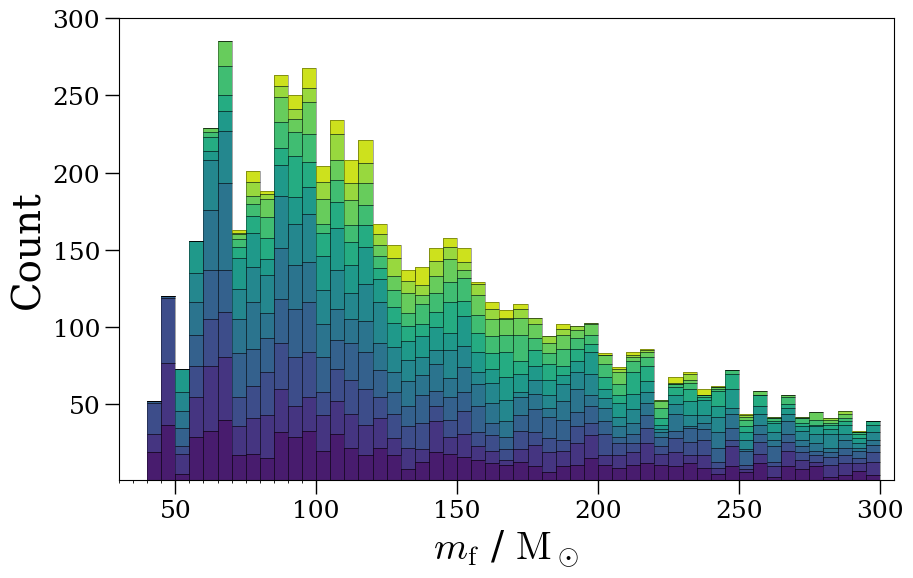

In [175]:
# plot settings
## data
log_z_div_zsun_edges = np.arange(-1.8, -0.4, 0.1)
m_f_bins = np.arange(10, 305, 5)

## look
figsize = (10, 6)
dpi = 100
cmap = cm.viridis

# plot setup
fig, ax = plt.subplots(figsize=figsize, dpi=dpi)

bin_width = m_f_bins[1] - m_f_bins[0]
bin_centers = 0.5 * (m_f_bins[:-1] + m_f_bins[1:])
bottom = np.zeros(len(bin_centers))

for i, (log_z_div_zsun_ledge, log_z_div_zsun_uedge) in enumerate(zip(log_z_div_zsun_edges[:-1], log_z_div_zsun_edges[1:])):
    color = cmap(i / (len(log_z_div_zsun_edges) - 1))
    z_div_zsun_mask = (sample00_df['z_div_zsun'] >= 10**log_z_div_zsun_ledge) & (sample00_df['z_div_zsun'] < 10**log_z_div_zsun_uedge)
    subset = sample00_df[z_div_zsun_mask]
    subset = subset[~np.isnan(subset['m_f'])]
    subset = subset[subset.log_t_d < 13.7]
    counts, _ = np.histogram(subset['m_zams'], bins=m_f_bins)
    ax.bar(bin_centers, counts, width=bin_width, bottom=bottom, facecolor=color, align='center')
    ax.bar(bin_centers, counts, width=bin_width, bottom=bottom, edgecolor='black', facecolor='none', alpha=0.5, lw=0.5, align='center')
    bottom += counts

#ax.set_yscale('log')
ax.set_ylim(1e0, 300)
ax.set_xticks(np.arange(10, 100, 5), minor=True)
ax.set_xlim(30, 305)
ax.set_xlabel(r'$m_\mathrm{f}$ / $\mathrm{M}_\odot$')
ax.set_ylabel('Count')
#ax.grid(True, which='both', axis='x', ls='-', alpha=1, color='black', lw=0.3)

## Step 3: metallicity distribution, fixed-redshift argument

In [342]:
MASS_COL = 'm_post_pi' # 'm_f'

In [343]:
Z_EVAL = 2.

bin_weights sum = 0.9955


Text(0, 0.5, '$p_Z \\cdot N$')

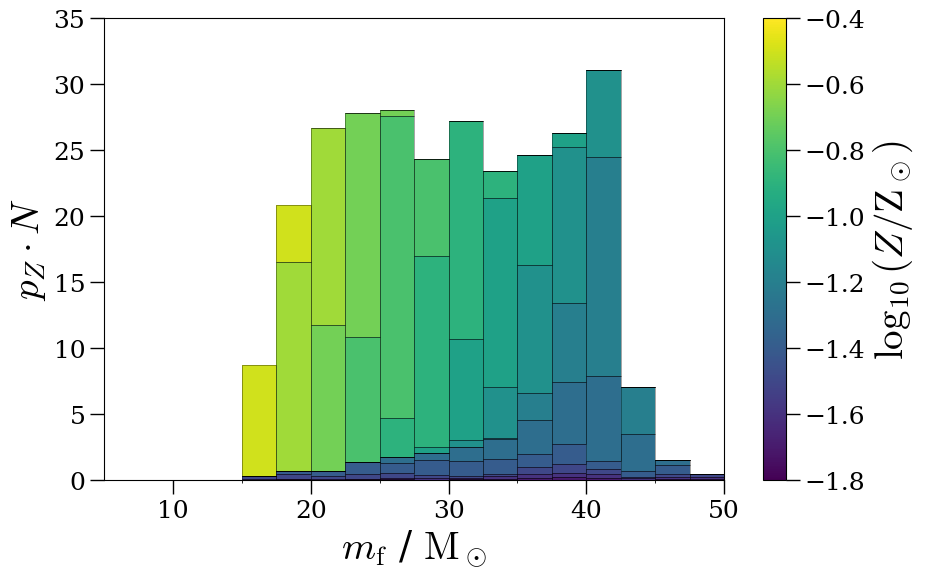

In [349]:
from src.merger_rates import (
    find_metallicity_distribution,
    DEFAULT_MU0, DEFAULT_MUZ, DEFAULT_SIGMA0, DEFAULT_SIGMAZ, DEFAULT_ALPHA,
)
from scipy.stats import gaussian_kde

# ── shared settings ───────────────────────────────────────────────────────────
Z_EVAL    = 3.
log_z_min, log_z_max = -1.8, -0.4
log_z_div_zsun_edges = np.arange(log_z_min, log_z_max + 0.05, 0.1)   # 14 bins
m_f_bins  = np.arange(15, 105, 2.5)
figsize   = (10, 6)
dpi       = 100
cmap      = cm.viridis

# ── van Son dp/dlogZ at z = Z_EVAL ───────────────────────────────────────────
min_lnz = np.log(Z_SUN * 10**log_z_min)
max_lnz = np.log(Z_SUN * 10**log_z_max)
dp_dlogz_2d, metals, _ = find_metallicity_distribution(
    redshifts=np.array([Z_EVAL]),
    min_logz_compas=min_lnz, max_logz_compas=max_lnz,
    mu0=DEFAULT_MU0, muz=DEFAULT_MUZ,
    sigma0=DEFAULT_SIGMA0, sigmaz=DEFAULT_SIGMAZ, alpha=DEFAULT_ALPHA,
    min_logz=min_lnz, max_logz=max_lnz, step_logz=0.005,
)
dp_dlogz_1d  = dp_dlogz_2d[0]
delta_lnZ    = (log_z_div_zsun_edges[1] - log_z_div_zsun_edges[0]) * np.log(10)
bin_lnZ_ctrs = np.log(Z_SUN * 10**(0.5*(log_z_div_zsun_edges[:-1] + log_z_div_zsun_edges[1:])))
bin_weights  = np.interp(bin_lnZ_ctrs, np.log(metals), dp_dlogz_1d) * delta_lnZ
print(f'bin_weights sum = {bin_weights.sum():.4f}')

# ── Plot 1: stacked weighted histogram ───────────────────────────────────────
fig, ax   = plt.subplots(figsize=figsize, dpi=dpi)
bin_width = m_f_bins[1] - m_f_bins[0]
mf_ctr    = 0.5*(m_f_bins[:-1] + m_f_bins[1:])
bottom    = np.zeros(len(mf_ctr))

for i, (ledge, uedge) in enumerate(zip(log_z_div_zsun_edges[:-1], log_z_div_zsun_edges[1:])):
    color = cmap(i / (len(log_z_div_zsun_edges) - 1))
    mask  = ( (sample00_df['z_div_zsun'] >= 10**ledge) &
              (sample00_df['z_div_zsun'] <  10**uedge) &
              ~np.isnan(sample00_df[MASS_COL]) &
              (sample00_df['log_t_d'] < 13.7) )
    counts, _ = np.histogram(sample00_df.loc[mask, MASS_COL], bins=m_f_bins)
    wcounts   = counts * bin_weights[i]
    ax.bar(mf_ctr, wcounts, width=bin_width, bottom=bottom, facecolor=color, align='center')
    ax.bar(mf_ctr, wcounts, width=bin_width, bottom=bottom,
           edgecolor='black', facecolor='none', alpha=0.5, lw=0.5, align='center')
    bottom += wcounts

norm_cbar = Normalize(vmin=log_z_min, vmax=log_z_max)
sm = ScalarMappable(cmap=cmap, norm=norm_cbar)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label(r'$\log_{10}(Z/\mathrm{Z}_\odot)$')

ax.set_xlim(5, 50.)
ax.set_ylim(0, 35)
ax.set_xticks(np.arange(15, 50, 5), minor=True)
ax.set_xlabel(MASS_LABEL)
ax.set_ylabel(r'$p_Z \cdot N$')

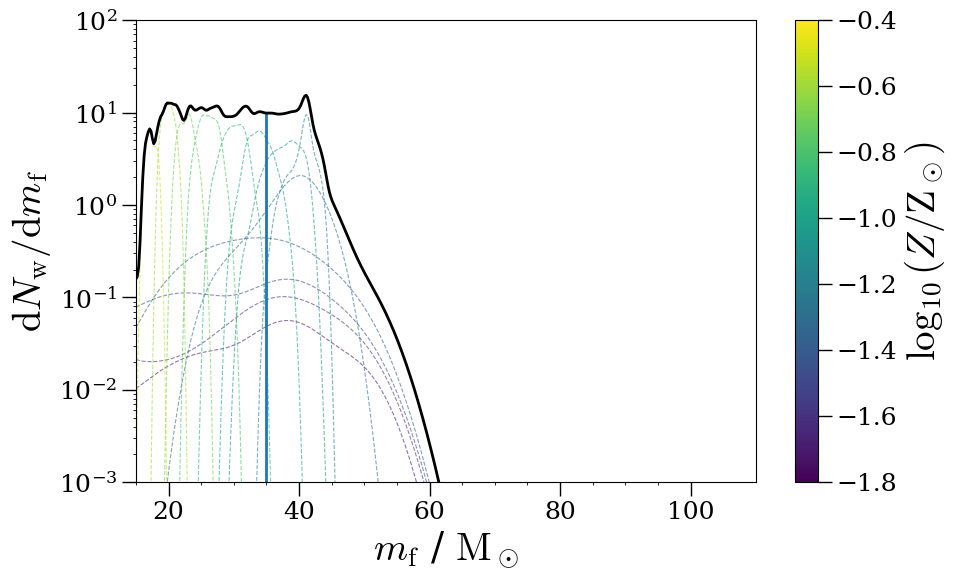

In [359]:
# ── Plot 2: overlapping weighted KDEs (dashed) + envelope (solid) ─────────────
# Uses a denser metallicity grid than Plot 1 so individual KDEs resolve fine structure
log_z_edges_dense = np.arange(log_z_min, log_z_max + 0.01, 0.1)   # step 0.02, ~70 bins

delta_lnZ_dense    = (log_z_edges_dense[1] - log_z_edges_dense[0]) * np.log(10)
bin_lnZ_ctrs_dense = np.log(Z_SUN * 10**(0.5*(log_z_edges_dense[:-1] + log_z_edges_dense[1:])))
bin_weights_dense  = np.interp(bin_lnZ_ctrs_dense, np.log(metals), dp_dlogz_1d) * delta_lnZ_dense

x_grid = np.linspace(15, 120, 500)

fig, ax      = plt.subplots(figsize=figsize, dpi=dpi)
envelope_kde = np.zeros(len(x_grid))

for i, (ledge, uedge) in enumerate(zip(log_z_edges_dense[:-1], log_z_edges_dense[1:])):
    color = cmap(i / (len(log_z_edges_dense) - 1))
    mask  = ( (sample00_df['z_div_zsun'] >= 10**ledge) &
              (sample00_df['z_div_zsun'] <  10**uedge) &
              ~np.isnan(sample00_df[MASS_COL]) &
              (sample00_df['log_t_d'] < 13.7) )
    sub = sample00_df.loc[mask, MASS_COL]
    if len(sub) < 2:
        continue
    kde   = gaussian_kde(sub)
    curve = kde(x_grid) * len(sub) * bin_weights_dense[i]
    ax.plot(x_grid, curve, color=color, lw=0.8, ls='--', alpha=0.6)
    envelope_kde += curve

ax.plot(x_grid, envelope_kde, color='black', lw=2, zorder=5)

norm_cbar = Normalize(vmin=log_z_min, vmax=log_z_max)
sm = ScalarMappable(cmap=cmap, norm=norm_cbar)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label(r'$\log_{10}(Z/\mathrm{Z}_\odot)$')

ax.set_yscale('log')
ax.set_ylim(1e-3, 1e2)
ax.set_xlim(15, 110)
ax.set_xticks(np.arange(15, 100, 5), minor=True)
ax.set_xlabel(MASS_LABEL)
ax.set_ylabel(MASS_DN_LABEL)

ax.vlines(35, 1e-5, 10)

# Step 4: What about delay times??

The plots in Step 3 are proportional to formation rates per redshift. To get a quantity proportional to merger rates per redshift, we need to account for delay. Roughly, we can create a delay time analogous plot, then scratch out any system with t_d > lookback_time(redshift). That will be the contribution of a given redshift to local mergers.

In [366]:
Z_EVAL = 1.0

log_td_cut = 9.895  (t_lookback at z=1.0)


Text(0, 0.5, '$p_Z \\cdot N$  (formation rate)')

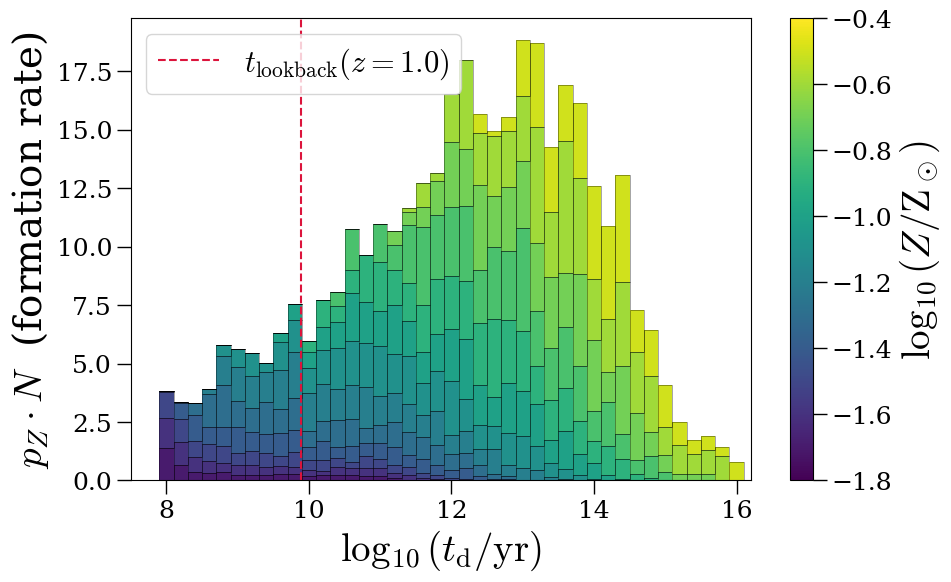

In [367]:
from src.constants import cosmo

# ── delay cut: lookback time to formation redshift Z_EVAL ────────────────────
log_td_cut = np.log10(cosmo.lookback_time(Z_EVAL).to(u.yr).value)
print(f'log_td_cut = {log_td_cut:.3f}  (t_lookback at z={Z_EVAL:.1f})')

# ── Plot 1: formation-rate delay-time histogram (NO delay cut) ────────────────
td_bins  = np.arange(7.5, 16.4, 0.2)
td_ctr   = 0.5*(td_bins[:-1] + td_bins[1:])
td_width = td_bins[1] - td_bins[0]

fig, ax  = plt.subplots(figsize=figsize, dpi=dpi)
bottom   = np.zeros(len(td_ctr))

for i, (ledge, uedge) in enumerate(zip(log_z_edges_dense[:-1], log_z_edges_dense[1:])):
    color = cmap(i / (len(log_z_edges_dense) - 1))
    mask  = ( (sample00_df['z_div_zsun'] >= 10**ledge) &
              (sample00_df['z_div_zsun'] <  10**uedge) &
              ~np.isnan(sample00_df[MASS_COL]) )
    counts, _ = np.histogram(sample00_df.loc[mask, 'log_t_d'], bins=td_bins)
    wcounts   = counts * bin_weights_dense[i]
    ax.bar(td_ctr, wcounts, width=td_width, bottom=bottom, facecolor=color, align='center')
    ax.bar(td_ctr, wcounts, width=td_width, bottom=bottom,
           edgecolor='black', facecolor='none', alpha=0.5, lw=0.5, align='center')
    bottom += wcounts

ax.axvline(log_td_cut, color='crimson', lw=1.5, ls='--',
           label=rf'$t_\mathrm{{lookback}}(z={Z_EVAL:.1f})$')
ax.legend()

norm_cbar = Normalize(vmin=log_z_min, vmax=log_z_max)
sm = ScalarMappable(cmap=cmap, norm=norm_cbar)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label(r'$\log_{10}(Z/\mathrm{Z}_\odot)$')

ax.set_xlim(7.5, 16.2)
ax.set_xlabel(r'$\log_{10}(t_\mathrm{d}/\mathrm{yr})$')
ax.set_ylabel(r'$p_Z \cdot N$  (formation rate)')

Text(0, 0.5, '$p_Z \\cdot N$  (merger rate)')

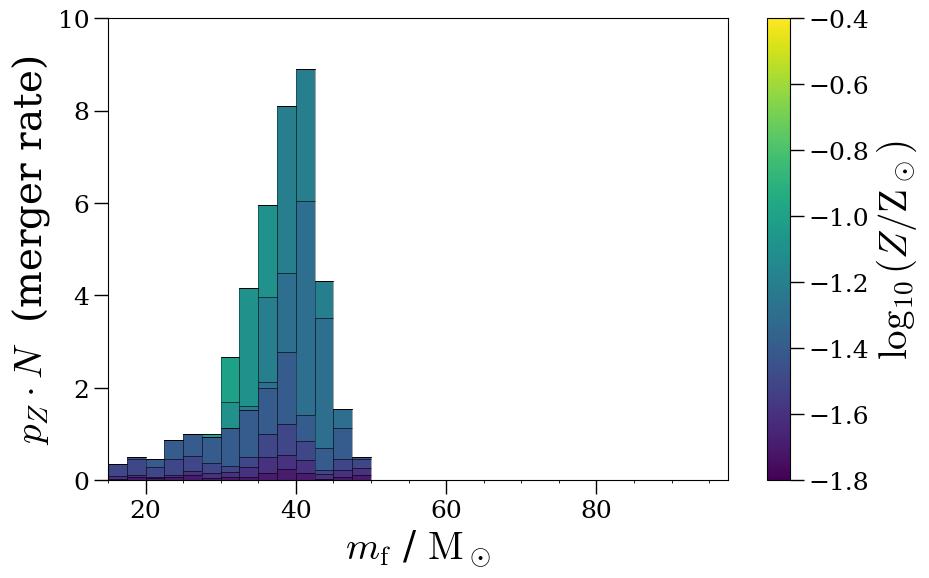

In [368]:
# ── Plot 2: merger-rate histogram (delay cut at lookback_time(Z_EVAL)) ────────
fig, ax   = plt.subplots(figsize=figsize, dpi=dpi)
bin_width = m_f_bins[1] - m_f_bins[0]
mf_ctr    = 0.5*(m_f_bins[:-1] + m_f_bins[1:])
bottom    = np.zeros(len(mf_ctr))

for i, (ledge, uedge) in enumerate(zip(log_z_edges_dense[:-1], log_z_edges_dense[1:])):
    color = cmap(i / (len(log_z_edges_dense) - 1))
    mask  = ( (sample00_df['z_div_zsun'] >= 10**ledge) &
              (sample00_df['z_div_zsun'] <  10**uedge) &
              ~np.isnan(sample00_df[MASS_COL]) &
              (sample00_df['log_t_d'] < log_td_cut) )
    counts, _ = np.histogram(sample00_df.loc[mask, MASS_COL], bins=m_f_bins)
    wcounts   = counts * bin_weights_dense[i]
    ax.bar(mf_ctr, wcounts, width=bin_width, bottom=bottom, facecolor=color, align='center')
    ax.bar(mf_ctr, wcounts, width=bin_width, bottom=bottom,
           edgecolor='black', facecolor='none', alpha=0.5, lw=0.5, align='center')
    bottom += wcounts

norm_cbar = Normalize(vmin=log_z_min, vmax=log_z_max)
sm = ScalarMappable(cmap=cmap, norm=norm_cbar)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label(r'$\log_{10}(Z/\mathrm{Z}_\odot)$')

ax.set_ylim(0, 10)
ax.set_xlim(15, 97.5)
ax.set_xticks(np.arange(15, 100, 5), minor=True)
ax.set_xlabel(MASS_LABEL)
ax.set_ylabel(r'$p_Z \cdot N$  (merger rate)')

In [ ]:
fiducial

NameError: name 'fiducial00_df' is not defined